# Reconstructing a navigator's planes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrmotion/blob/main/examples/01-navigator.ipynb)

A navigator is a handful of low-resolution planes acquired between the
imaging blocks of a scan. This one starts at k-space samples along a radial
trajectory and ends at a plane good enough to register: what the trajectory's
extent sets, what weighting each sample by its own sampling density is worth,
and how the result compares with the full-resolution image it was cut from.
The anatomy is a real brain slice from the
[ISMRM motion-correction workshop](https://github.com/lab-midas/ismrm-moco-workshop)
(MIT).


This notebook goes the whole way: k-space samples along a radial navigator
trajectory, gridded into planes, registered against the first navigator of the
scan, solved for a pose, and carried across the scan by an extended Kalman
filter. The anatomy is a real brain slice from the
[ISMRM motion-correction workshop](https://github.com/lab-midas/ismrm-moco-workshop)
(MIT).

In [1]:
try:
    import mrmotion  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "mrmotion",
            "finufft",
            "scipy",
            "matplotlib",
        ],
        check=True,
    )

In [2]:
import io
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import rotate, shift

import mrmotion as mm

WORKSHOP = (
    "https://raw.githubusercontent.com/lab-midas/"
    "ismrm-moco-workshop/master/data/brain_slice.npz"
)
with urllib.request.urlopen(WORKSHOP) as response:
    series = np.load(io.BytesIO(response.read()))["arr_0"]

brain = np.abs(series[20:236, :, 0])  # one frame, cropped square
brain /= brain.max()
print("anatomy", brain.shape)

anatomy (216, 216)


## What the navigator acquires, and what its trajectory extent means

A navigator's trajectory is given in cycles per field of view, running over
$[-\tfrac{1}{2}, \tfrac{1}{2}]$ across the grid it is reconstructed onto. So
the extent of the trajectory in the *scanner's* k-space is what sets the
navigator's resolution: sampling out to a fraction $g/N$ of the imaging
Nyquist and gridding onto a $g \times g$ matrix gives a plane at the full
field of view and $N/g$ times coarser, which is what a navigator is. Sampling
out to the imaging Nyquist and gridding onto the same small matrix would give
something else entirely -- full resolution over a fraction of the field of
view, aliased.

Golden-angle spokes are used here so that any consecutive run of them covers
k-space about as evenly as any other.

/home/mcencini/mrmotion/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


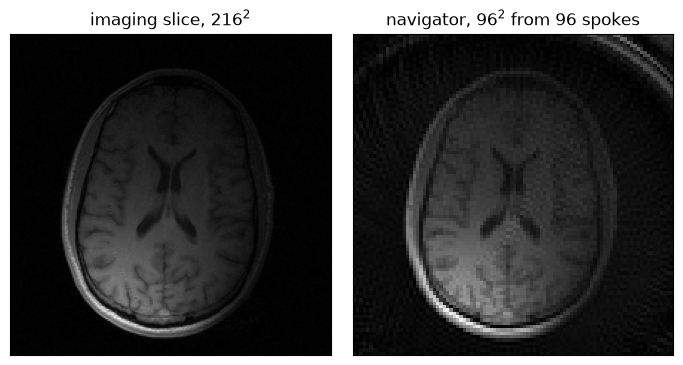

In [3]:
import finufft

GRID = 96  # navigator matrix
SPOKES = 96
N = brain.shape[0]


def radial(samples, spokes):
    """Golden-angle radial spokes, in cycles per field of view."""
    angles = np.arange(spokes) * np.pi * (3 - np.sqrt(5))
    radius = np.linspace(-0.5, 0.5, samples, endpoint=False)
    return np.stack(
        [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)],
        axis=-1,
    ).reshape(-1, 2)


def acquire(image, trajectory):
    """What the scanner measures of ``image`` along a navigator trajectory."""
    scaled = 2 * np.pi * trajectory * GRID / N  # navigator extent of image k-space
    return finufft.nufft2d2(
        np.ascontiguousarray(scaled[:, 0]),
        np.ascontiguousarray(scaled[:, 1]),
        np.ascontiguousarray(image.astype(np.complex128)),
        isign=-1,
        eps=1e-6,
        nthreads=1,
    )


trajectory = radial(GRID, SPOKES)
density = mm.estimate_density(trajectory, (GRID, GRID))

plane = mm.reconstruct_navigator(
    acquire(brain, trajectory)[None, None],  # (planes, coils, samples)
    trajectory[None],  # (planes, samples, 2)
    (GRID, GRID),
    density=density[None],
)[0]

figure, axes = plt.subplots(1, 2, figsize=(7, 3.6))
axes[0].imshow(brain, cmap="gray")
axes[0].set_title(f"imaging slice, {N}$^2$")
axes[1].imshow(plane, cmap="gray")
axes[1].set_title(f"navigator, {GRID}$^2$ from {SPOKES} spokes")
for panel in axes:
    panel.set_xticks([])
    panel.set_yticks([])
figure.tight_layout()

## Weighting each sample by how densely it was visited

Radial spokes cross at the centre of k-space and separate towards the edge, so
the adjoint of the sampling operator counts the low frequencies many times over
and the high frequencies once. Undoing that is a per-sample weight, and the
weight depends on the trajectory alone -- not on the data, and not on the head
-- so `estimate_density` runs once, when the application learns the
trajectory, and never again during the scan.

The analytic ramp $|k|$ is the usual shortcut and it is wrong where it costs
most. It keeps growing with radius while the spokes are separating faster than
the gridding kernel is wide, so it over-weights exactly the outer k-space the
navigator has left sparse: the plane comes back with an edge-enhanced rim and
streaks across the background. The Pipe-Menon fixed point measures the density
the reconstruction actually sees, and stops growing where the ramp's assumption
fails.

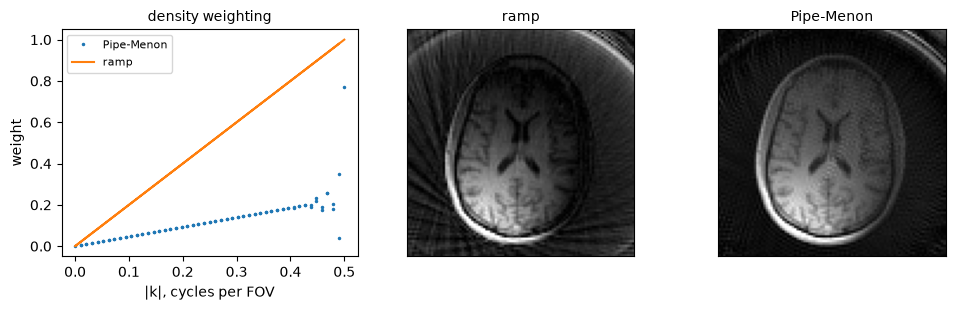

In [4]:
ramp = np.tile(np.abs(np.linspace(-0.5, 0.5, GRID, endpoint=False)), SPOKES)

figure, axes = plt.subplots(1, 3, figsize=(10, 3.2))
spoke = np.abs(np.linspace(-0.5, 0.5, GRID, endpoint=False))
axes[0].plot(
    spoke,
    density.reshape(SPOKES, GRID).mean(axis=0) / density.max(),
    ".",
    ms=3,
    label="Pipe-Menon",
)
axes[0].plot(spoke, ramp[:GRID] / ramp.max(), "-", label="ramp")
axes[0].set_xlabel("|k|, cycles per FOV")
axes[0].set_ylabel("weight")
axes[0].legend(fontsize=8)
axes[0].set_title("density weighting", fontsize=10)
for panel, weights, name in zip(
    axes[1:], (ramp, density), ("ramp", "Pipe-Menon"), strict=True
):
    image = mm.reconstruct_navigator(
        acquire(brain, trajectory)[None, None],
        trajectory[None],
        (GRID, GRID),
        density=weights[None],
    )[0]
    panel.imshow(image, cmap="gray", vmax=np.percentile(image, 99.5))
    panel.set_xticks([])
    panel.set_yticks([])
    panel.set_title(name, fontsize=10)
figure.tight_layout()

## The navigator measures what the image measures

Move the anatomy by a known amount, acquire a navigator of it, and register
that navigator against the one acquired before the motion. The number to beat
is what the same registration gets from the full-resolution images, because
that is the best a 2D registration of this anatomy can do -- the navigator
should not be much worse.

In [5]:
registration = mm.RigidRegistration()


def moved(image, degrees, offset):
    return shift(rotate(image, degrees, reshape=False, order=3), offset, order=3)


print(f"{'truth':^27}{'full image':^27}{'navigator':^27}")
for degrees, offset in [(3.0, (4.0, -6.0)), (8.0, (-10.0, 5.0)), (0.0, (12.0, 12.0))]:
    other = moved(brain, degrees, offset)

    full = registration(brain, other, spacing=(1.0, 1.0)).parameters
    planes = [
        mm.reconstruct_navigator(
            acquire(image, trajectory)[None, None],
            trajectory[None],
            (GRID, GRID),
            density=density[None],
        )[0]
        for image in (brain, other)
    ]
    nav = np.asarray(registration(*planes, spacing=(1.0, 1.0)).parameters)
    nav[1:] *= N / GRID  # navigator pixels -> image pixels

    def show(values):
        return (
            f"{np.degrees(values[0]):7.2f} deg {values[1]:7.2f} {values[2]:7.2f} px  "
        )

    print(show([np.radians(-degrees), offset[1], offset[0]]) + show(full) + show(nav))

           truth                   full image                  navigator         
  -3.00 deg   -6.00    4.00 px    -2.99 deg   -6.01    4.00 px    -2.90 deg   -6.04    3.96 px  
  -8.00 deg    5.00  -10.00 px    -7.16 deg    5.35   -9.99 px    -8.03 deg    4.89   -9.93 px  
  -0.00 deg   12.00   12.00 px     0.07 deg   12.03   12.01 px     0.00 deg   11.98   11.95 px  


Both come back through the navigator to about a tenth of a unit -- a tenth of
an imaging pixel, a tenth of a degree -- on motion large enough that the
full-resolution registration is a degree off itself. With the ramp in place of
the estimated density the rotation error is 1.5$^\\circ$ and the translation
error nearly a pixel, so the weighting is not a refinement of the picture: it
is most of the measurement.

## Coils

A navigator arrives one array element at a time and is combined by root sum of
squares, which needs no sensitivity maps -- the planes are registered against
each other, not diagnosed, and a magnitude is all a registration reads. Pass
`(planes, coils, samples)` and the coil axis is consumed.

8 coils, truth 12.00 12.00 px:  11.89  11.96 px


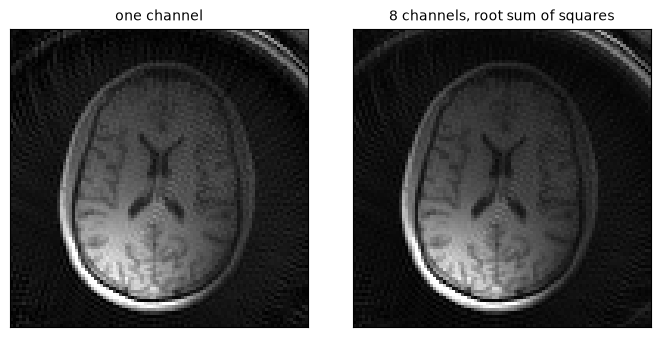

In [6]:
COILS = 8
rows, columns = np.mgrid[0:N, 0:N] / N
sensitivities = np.stack(
    [
        np.exp(
            -(
                (columns - 0.5 - 0.6 * np.cos(angle)) ** 2
                + (rows - 0.5 - 0.6 * np.sin(angle)) ** 2
            )
            / 0.35
        )
        for angle in np.linspace(0, 2 * np.pi, COILS, endpoint=False)
    ]
)

array = np.stack(
    [acquire(sensitivity * brain, trajectory) for sensitivity in sensitivities]
)
combined = mm.reconstruct_navigator(
    array[None], trajectory[None], (GRID, GRID), density=density[None]
)[0]

single = mm.reconstruct_navigator(
    acquire(brain, trajectory)[None, None],
    trajectory[None],
    (GRID, GRID),
    density=density[None],
)[0]

shifted = np.stack(
    [
        acquire(sensitivity * moved(brain, 0.0, (12.0, 12.0)), trajectory)
        for sensitivity in sensitivities
    ]
)
elsewhere = mm.reconstruct_navigator(
    shifted[None], trajectory[None], (GRID, GRID), density=density[None]
)[0]
pose = np.asarray(registration(combined, elsewhere, spacing=(1.0, 1.0)).parameters)
print(
    f"{COILS} coils, truth 12.00 12.00 px:"
    f" {pose[1] * N / GRID:6.2f} {pose[2] * N / GRID:6.2f} px"
)

figure, axes = plt.subplots(1, 2, figsize=(7, 3.4))
for panel, image, title in zip(
    axes,
    (single, combined),
    ("one channel", f"{COILS} channels, root sum of squares"),
    strict=True,
):
    panel.imshow(image, cmap="gray", vmax=np.percentile(image, 99.5))
    panel.set_xticks([])
    panel.set_yticks([])
    panel.set_title(title, fontsize=10)
figure.tight_layout()